# Evaluate A Checkpoint Against All Anchors

Loads one checkpoint (default: latest), loads all legacy anchors, then plays 100 stochastic games against each anchor with colors split 50/50.

In [1]:
from pathlib import Path
import json
import sys
import time

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import clear_output

from src.Env import Env
from src.MCTS import MCTS, Node
from src.elo_history import checkpoint_iteration
from src.models import LegacyPVModel, PVModel

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_SIMULATIONS = 25
C_PUCT = 1.5
TEMPERATURE = 0.5
GAMES_PER_ANCHOR = 10
CHECKPOINT_STEP = 50
MOVING_AVERAGE_WIDTH = int(CHECKPOINT_STEP * 1.5)
SEED = 0

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
ANCHOR_DIR = PROJECT_ROOT / "anchors" / "legacy_pv_model"
ANCHOR_MANIFEST_PATH = ANCHOR_DIR / "anchors.json"

assert GAMES_PER_ANCHOR % 2 == 0, "GAMES_PER_ANCHOR must be even so colors are split 50/50."

In [3]:
def resolve_checkpoint_path(checkpoint):
    if checkpoint == "last":
        checkpoint_paths = sorted(
            CHECKPOINT_DIR.glob("iteration_*.pt"),
            key=checkpoint_iteration,
        )
        if not checkpoint_paths:
            raise FileNotFoundError("No checkpoints found in checkpoints/.")
        return checkpoint_paths[-1].resolve()

    checkpoint_number = int(checkpoint)
    checkpoint_path = CHECKPOINT_DIR / f"iteration_{checkpoint_number}.pt"
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
    return checkpoint_path.resolve()


def select_checkpoint_paths(step: int):
    checkpoint_paths = sorted(
        CHECKPOINT_DIR.glob("iteration_*.pt"),
        key=checkpoint_iteration,
    )
    if not checkpoint_paths:
        raise FileNotFoundError("No checkpoints found in checkpoints/.")

    selected = [path.resolve() for path in checkpoint_paths if checkpoint_iteration(path) % step == 0]
    last_checkpoint_path = checkpoint_paths[-1].resolve()
    if not selected or selected[-1] != last_checkpoint_path:
        selected.append(last_checkpoint_path)
    return selected


def load_anchors():
    manifest = json.loads(ANCHOR_MANIFEST_PATH.read_text(encoding="utf-8"))
    anchors = []
    for entry in manifest["anchors"]:
        anchor_path = (ANCHOR_DIR / entry["checkpoint"]).resolve()
        anchors.append(
            {
                "name": Path(entry["checkpoint"]).stem,
                "path": anchor_path,
                "iteration": int(entry["iteration"]),
                "elo": float(entry["elo"]),
            }
        )
    return anchors


def build_model_for_path(model_path: Path):
    if model_path.parent.resolve() == ANCHOR_DIR.resolve():
        return LegacyPVModel()
    return PVModel()


def load_model(model_path: Path, device: str):
    checkpoint = torch.load(model_path, map_location=device)
    model = build_model_for_path(model_path).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


def load_anchor_models(device: str):
    anchors = load_anchors()
    loaded_anchors = []
    for anchor in anchors:
        loaded_anchor = dict(anchor)
        loaded_anchor["model"] = load_model(anchor["path"], device)
        loaded_anchors.append(loaded_anchor)
    return loaded_anchors


def score_from_result(result, checkpoint_is_player_one: bool):
    if checkpoint_is_player_one:
        if result == -1:
            return 1.0
        if result == 0:
            return 0.5
        return 0.0

    if result == 1:
        return 1.0
    if result == 0:
        return 0.5
    return 0.0


class DirectBatchEvaluator:
    def __init__(self, model, device: str):
        self.model = model
        self.device = device
        self.cache = {}

    def evaluate_states(self, canonical_states):
        if not canonical_states:
            return [], []

        policy_logits_batch = [None] * len(canonical_states)
        value_batch = [None] * len(canonical_states)
        uncached_indices = []
        uncached_states = []
        uncached_keys = []

        for index, canonical_state in enumerate(canonical_states):
            state = np.ascontiguousarray(canonical_state, dtype=np.float32)
            state_key = state.tobytes()
            cached_evaluation = self.cache.get(state_key)
            if cached_evaluation is not None:
                policy_logits_batch[index], value_batch[index] = cached_evaluation
                continue

            uncached_indices.append(index)
            uncached_states.append(state)
            uncached_keys.append(state_key)

        if uncached_states:
            x_batch = torch.as_tensor(
                np.stack(uncached_states),
                dtype=torch.float32,
                device=self.device,
            )
            with torch.inference_mode():
                policy_logits_tensor, value_tensor = self.model(x_batch)
            uncached_policy_logits = policy_logits_tensor.detach().cpu().numpy()
            uncached_values = value_tensor.squeeze(-1).detach().cpu().numpy()

            for index, state_key, policy_logits, value in zip(
                uncached_indices,
                uncached_keys,
                uncached_policy_logits,
                uncached_values,
            ):
                evaluation = (policy_logits, float(value))
                self.cache[state_key] = evaluation
                policy_logits_batch[index], value_batch[index] = evaluation

        return policy_logits_batch, value_batch


def advance_root(root, action: int):
    if root is None:
        return None

    root = root.children.get(action)
    if root is not None:
        root.prior = 1.0
    return root


def expand_pending_nodes(pending_nodes, evaluator, mcts_helper, backpropagate: bool):
    if not pending_nodes:
        return

    canonical_states = [
        pending_node["env"].canonical_state(
            perspective_player=pending_node["node"].player_to_play
        )
        for pending_node in pending_nodes
    ]
    policy_logits_batch, value_batch = evaluator.evaluate_states(canonical_states)

    for pending_node, policy_logits, value in zip(
        pending_nodes,
        policy_logits_batch,
        value_batch,
    ):
        mcts_helper.expand_from_evaluation(
            node=pending_node["node"],
            env=pending_node["env"],
            policy_logits=policy_logits,
            value=float(value),
        )

        if backpropagate:
            mcts_helper._backpropagate(
                pending_node["path"],
                float(value),
            )

        while pending_node["applied_actions"]:
            pending_node["env"].undo_action(pending_node["applied_actions"].pop())


def run_batched_mcts_for_side(live_games, root_key: str, evaluator, mcts_helper):
    if not live_games:
        return

    root_expansions = []
    for live_game in live_games:
        root = live_game[root_key]
        if root is None:
            root = Node(prior=1.0, player_to_play=live_game["env"].current_player())
            live_game[root_key] = root

        if not root.is_expanded:
            root_expansions.append(
                {
                    "node": root,
                    "env": live_game["env"],
                    "path": [root],
                    "applied_actions": [],
                }
            )

    expand_pending_nodes(root_expansions, evaluator, mcts_helper, backpropagate=False)

    for _ in range(mcts_helper.num_simulations):
        pending_nodes = []

        for live_game in live_games:
            env = live_game["env"]
            node = live_game[root_key]
            path = [node]
            applied_actions = []

            while node.is_expanded and len(node.children) > 0:
                action, child = mcts_helper._select_child(node)
                env.step(action)
                applied_actions.append(action)
                node = child
                path.append(node)

                if env.is_terminal():
                    break

            if env.is_terminal():
                value = env.terminal_value(node.player_to_play)
                mcts_helper._backpropagate(path, value)
                while applied_actions:
                    env.undo_action(applied_actions.pop())
            else:
                pending_nodes.append(
                    {
                        "node": node,
                        "env": env,
                        "path": path,
                        "applied_actions": applied_actions,
                    }
                )

        expand_pending_nodes(pending_nodes, evaluator, mcts_helper, backpropagate=True)


def initialize_live_games_for_anchor(games_per_anchor: int, seed: int):
    half_games = games_per_anchor // 2
    live_games = []

    for game_index in range(half_games):
        live_games.append(
            {
                "env": Env(),
                "rng": np.random.default_rng(seed + game_index),
                "checkpoint_as_player": -1,
                "checkpoint_root": None,
                "anchor_root": None,
            }
        )

    for game_index in range(half_games):
        live_games.append(
            {
                "env": Env(),
                "rng": np.random.default_rng(seed + half_games + game_index),
                "checkpoint_as_player": 1,
                "checkpoint_root": None,
                "anchor_root": None,
            }
        )

    return live_games


def evaluate_checkpoint_model_vs_anchors(
    checkpoint_model,
    anchors,
    games_per_anchor: int,
    seed: int,
    progress_callback=None,
    anchor_progress_callback=None,
):
    checkpoint_evaluator = DirectBatchEvaluator(checkpoint_model, DEVICE)
    checkpoint_mcts_helper = MCTS(
        model=None,
        num_simulations=NUM_SIMULATIONS,
        c_puct=C_PUCT,
        add_exploration_noise=False,
    )
    anchor_mcts_helper = MCTS(
        model=None,
        num_simulations=NUM_SIMULATIONS,
        c_puct=C_PUCT,
        add_exploration_noise=False,
    )

    anchor_matches = []
    for anchor_index, anchor in enumerate(anchors, start=1):
        anchor_matches.append(
            {
                "anchor": anchor,
                "evaluator": DirectBatchEvaluator(anchor["model"], DEVICE),
                "live_games": initialize_live_games_for_anchor(
                    games_per_anchor=games_per_anchor,
                    seed=seed + anchor_index * 100_000,
                ),
                "wins": 0,
                "draws": 0,
                "losses": 0,
            }
        )

    total_anchors = len(anchor_matches)
    completed_rows = []
    completed_anchor_matches = 0

    while anchor_matches:
        checkpoint_turn_games = []
        for anchor_match in anchor_matches:
            checkpoint_turn_games.extend(
                live_game
                for live_game in anchor_match["live_games"]
                if live_game["env"].current_player() == live_game["checkpoint_as_player"]
            )

        run_batched_mcts_for_side(
            checkpoint_turn_games,
            root_key="checkpoint_root",
            evaluator=checkpoint_evaluator,
            mcts_helper=checkpoint_mcts_helper,
        )

        for anchor_match in anchor_matches:
            anchor_turn_games = [
                live_game
                for live_game in anchor_match["live_games"]
                if live_game["env"].current_player() != live_game["checkpoint_as_player"]
            ]
            run_batched_mcts_for_side(
                anchor_turn_games,
                root_key="anchor_root",
                evaluator=anchor_match["evaluator"],
                mcts_helper=anchor_mcts_helper,
            )

        next_anchor_matches = []
        for anchor_match in anchor_matches:
            next_live_games = []

            for live_game in anchor_match["live_games"]:
                checkpoint_turn = (
                    live_game["env"].current_player() == live_game["checkpoint_as_player"]
                )
                if checkpoint_turn:
                    root = live_game["checkpoint_root"]
                    pi = checkpoint_mcts_helper.visit_counts_to_policy(
                        root=root,
                        temperature=TEMPERATURE,
                    )
                else:
                    root = live_game["anchor_root"]
                    pi = anchor_mcts_helper.visit_counts_to_policy(
                        root=root,
                        temperature=TEMPERATURE,
                    )

                action = int(live_game["rng"].choice(len(pi), p=pi))
                live_game["env"].step(action)
                live_game["checkpoint_root"] = advance_root(live_game["checkpoint_root"], action)
                live_game["anchor_root"] = advance_root(live_game["anchor_root"], action)

                if live_game["env"].is_terminal():
                    score = score_from_result(
                        live_game["env"].winner(),
                        checkpoint_is_player_one=(live_game["checkpoint_as_player"] == -1),
                    )
                    if score == 1.0:
                        anchor_match["wins"] += 1
                    elif score == 0.5:
                        anchor_match["draws"] += 1
                    else:
                        anchor_match["losses"] += 1
                    if progress_callback is not None:
                        progress_callback()
                else:
                    next_live_games.append(live_game)

            anchor_match["live_games"] = next_live_games
            if anchor_match["live_games"]:
                next_anchor_matches.append(anchor_match)
                continue

            completed_anchor_matches += 1
            completed_rows.append(
                {
                    "anchor_elo": anchor_match["anchor"]["elo"],
                    "anchor_name": anchor_match["anchor"]["name"],
                    "wins": anchor_match["wins"],
                    "draws": anchor_match["draws"],
                    "losses": anchor_match["losses"],
                    "score_percent": 100.0 * (
                        anchor_match["wins"] + 0.5 * anchor_match["draws"]
                    ) / games_per_anchor,
                }
            )
            if anchor_progress_callback is not None:
                anchor_progress_callback(
                    completed_anchor_matches,
                    total_anchors,
                    anchor_match["anchor"]["elo"],
                )

        anchor_matches = next_anchor_matches

    return completed_rows


def print_results_table(rows):
    headers = ("Anchor Elo", "Anchor", "Wins", "Draws", "Losses", "Score %")
    string_rows = [
        (
            f"{row['anchor_elo']:.1f}",
            row["anchor_name"],
            str(row["wins"]),
            str(row["draws"]),
            str(row["losses"]),
            f"{row['score_percent']:.1f}%",
        )
        for row in rows
    ]
    widths = [len(header) for header in headers]
    for row in string_rows:
        for column_index, value in enumerate(row):
            widths[column_index] = max(widths[column_index], len(value))

    def format_row(values):
        return " | ".join(value.ljust(widths[index]) for index, value in enumerate(values))

    print(format_row(headers))
    print("-+-".join("-" * width for width in widths))
    for row in string_rows:
        print(format_row(row))


def moving_average(values, width):
    values = np.asarray(values, dtype=np.float64)
    if values.size == 0:
        return values
    width = max(1, min(int(width), int(values.size)))
    kernel = np.ones(width, dtype=np.float64)
    counts = np.convolve(np.ones_like(values), kernel, mode="same")
    totals = np.convolve(values, kernel, mode="same")
    if totals.shape != values.shape:
        totals = totals[: values.size]
        counts = counts[: values.size]
    return totals / counts


def format_duration(seconds):
    seconds = max(0, int(round(seconds)))
    hours, remainder = divmod(seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    if hours > 0:
        return f"{hours}h {minutes:02d}m {seconds:02d}s"
    if minutes > 0:
        return f"{minutes}m {seconds:02d}s"
    return f"{seconds}s"


def format_progress_bar(label, current, total, width=28, eta_seconds=None):
    total = max(1, int(total))
    current = min(int(current), total)
    filled = int(round(width * current / total))
    bar = "#" * filled + "-" * (width - filled)
    percent = 100.0 * current / total
    eta_text = ""
    if eta_seconds is not None:
        eta_text = f" | ETA {format_duration(eta_seconds)}"
    return f"{label:<18} [{bar}] {current}/{total} ({percent:.1f}%){eta_text}"


def render_progress(progress_state, total_games, num_checkpoints, num_anchors):
    elapsed_seconds = max(0.0, progress_state.get("elapsed_seconds", 0.0))
    games_done = int(progress_state["games_done"])
    eta_games = None
    if games_done > 0 and elapsed_seconds > 0:
        games_per_second = games_done / elapsed_seconds
        remaining_games = max(0, total_games - games_done)
        eta_games = remaining_games / games_per_second if games_per_second > 0 else None

    clear_output(wait=True)
    print(f"Device: {DEVICE}")
    print(f"Checkpoint step: {CHECKPOINT_STEP}")
    print(f"Selected checkpoints: {num_checkpoints}")
    print(f"Games per anchor: {GAMES_PER_ANCHOR}")
    print(f"Temperature: {TEMPERATURE}")
    print(f"Moving average width: {MOVING_AVERAGE_WIDTH}")
    print()
    print(f"Current checkpoint: {progress_state['current_checkpoint']}")
    print(f"Current anchor: {progress_state['current_anchor']}")
    print()
    print(format_progress_bar("Games total", progress_state["games_done"], total_games, eta_seconds=eta_games))
    print(format_progress_bar("Checkpoints", progress_state["checkpoint_index"], num_checkpoints))
    print(format_progress_bar("Anchors", progress_state["anchor_index"], num_anchors))


In [4]:
checkpoint_paths = select_checkpoint_paths(CHECKPOINT_STEP)
anchors = load_anchor_models(DEVICE)

total_games = len(checkpoint_paths) * len(anchors) * GAMES_PER_ANCHOR
results = []
progress_state = {
    "games_done": 0,
    "checkpoint_index": 0,
    "anchor_index": 0,
    "current_checkpoint": "-",
    "current_anchor": "-",
    "started_at": time.perf_counter(),
    "elapsed_seconds": 0.0,
}

def on_game_finished():
    progress_state["games_done"] += 1
    progress_state["elapsed_seconds"] = time.perf_counter() - progress_state["started_at"]
    render_progress(progress_state, total_games, len(checkpoint_paths), len(anchors))


def on_anchor_finished(completed_anchor_count, total_anchor_count, anchor_elo):
    progress_state["anchor_index"] = completed_anchor_count
    progress_state["current_anchor"] = (
        f"parallel ({completed_anchor_count}/{total_anchor_count} done, latest {anchor_elo:.1f})"
    )
    progress_state["elapsed_seconds"] = time.perf_counter() - progress_state["started_at"]
    render_progress(progress_state, total_games, len(checkpoint_paths), len(anchors))

render_progress(progress_state, total_games, len(checkpoint_paths), len(anchors))

for checkpoint_index, checkpoint_path in enumerate(checkpoint_paths, start=1):
    checkpoint_model = load_model(checkpoint_path, DEVICE)
    checkpoint_iteration_value = checkpoint_iteration(checkpoint_path)
    progress_state["checkpoint_index"] = checkpoint_index
    progress_state["current_checkpoint"] = checkpoint_iteration_value
    progress_state["anchor_index"] = 0
    progress_state["current_anchor"] = "parallel"
    render_progress(progress_state, total_games, len(checkpoint_paths), len(anchors))

    checkpoint_rows = evaluate_checkpoint_model_vs_anchors(
        checkpoint_model=checkpoint_model,
        anchors=anchors,
        games_per_anchor=GAMES_PER_ANCHOR,
        seed=SEED + checkpoint_index * 1_000_000,
        progress_callback=on_game_finished,
        anchor_progress_callback=on_anchor_finished,
    )
    for row in checkpoint_rows:
        row["checkpoint_iteration"] = checkpoint_iteration_value
        results.append(row)

progress_state["current_anchor"] = "done"
render_progress(progress_state, total_games, len(checkpoint_paths), len(anchors))

latest_iteration = checkpoint_iteration(checkpoint_paths[-1])
latest_results = [row for row in results if row["checkpoint_iteration"] == latest_iteration]
latest_results.sort(key=lambda row: row["anchor_elo"], reverse=True)
print()
print_results_table(latest_results)


Device: cuda
Checkpoint step: 50
Selected checkpoints: 16
Games per anchor: 10
Temperature: 0.5
Moving average width: 75

Current checkpoint: 750
Current anchor: done

Games total        [############################] 1120/1120 (100.0%) | ETA 0s
Checkpoints        [############################] 16/16 (100.0%)
Anchors            [############################] 7/7 (100.0%)

Anchor Elo | Anchor          | Wins | Draws | Losses | Score %
-----------+-----------------+------+-------+--------+--------
724.9      | run_1_elo_724.9 | 7    | 0     | 3      | 70.0%  
653.0      | run_1_elo_653.0 | 8    | 0     | 2      | 80.0%  
597.1      | run_1_elo_597.1 | 8    | 0     | 2      | 80.0%  
558.3      | run_1_elo_558.3 | 9    | 0     | 1      | 90.0%  
498.6      | run_1_elo_498.6 | 8    | 0     | 2      | 80.0%  
447.7      | run_1_elo_447.7 | 6    | 0     | 4      | 60.0%  
411.8      | run_1_elo_411.8 | 1    | 0     | 9      | 10.0%  


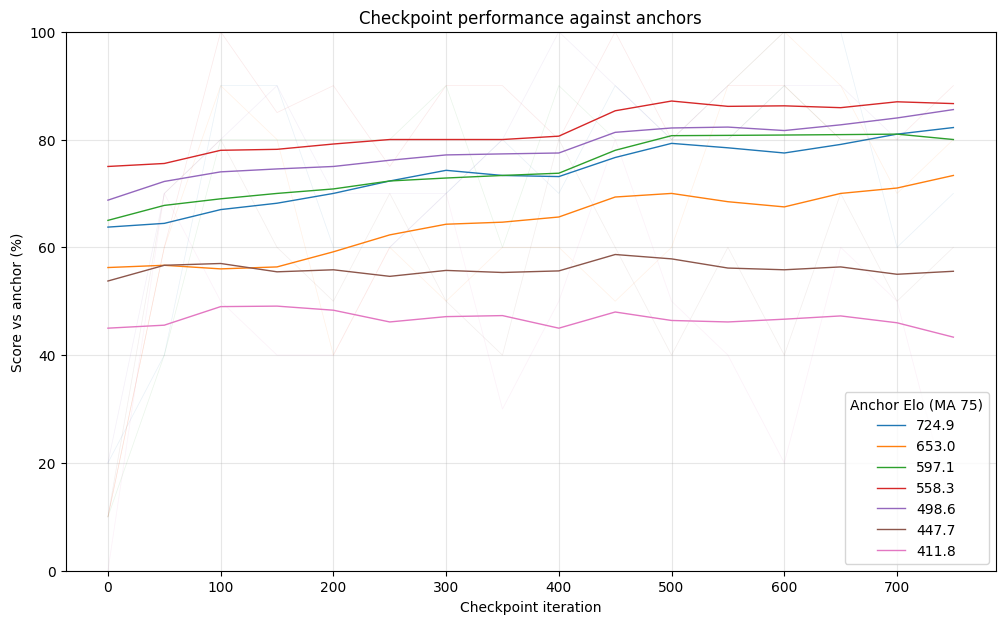

In [5]:
plt.figure(figsize=(12, 7))
for anchor in sorted(anchors, key=lambda item: item["elo"], reverse=True):
    anchor_rows = [row for row in results if row["anchor_name"] == anchor["name"]]
    anchor_rows.sort(key=lambda row: row["checkpoint_iteration"])
    x_values = [row["checkpoint_iteration"] for row in anchor_rows]
    y_values = np.asarray([row["score_percent"] for row in anchor_rows], dtype=np.float64)
    ma_values = moving_average(y_values, MOVING_AVERAGE_WIDTH)

    raw_line = plt.plot(
        x_values,
        y_values,
        linewidth=0.5,
        alpha=0.1,
    )[0]
    plt.plot(
        x_values,
        ma_values,
        linewidth=1,
        color=raw_line.get_color(),
        label=f"{anchor['elo']:.1f}",
    )

plt.xlabel("Checkpoint iteration")
plt.ylabel("Score vs anchor (%)")
plt.title("Checkpoint performance against anchors")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(title=f"Anchor Elo (MA {MOVING_AVERAGE_WIDTH})")
plt.show()